# Part 1 - Text Generation

Introduction

In this notebook, we implement a Transformer-based text generation model from scratch using Keras.

The goal is to:

- understand how Transformer models work internally
- train a small language model without pretraining
- generate text based on a given prompt
- analyze how model size and temperature affect output quality
- explore the trade-off between training speed and generation quality



In [3]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.13.2
Keras backend: tensorflow


## Dataset

The dataset used in this project is Kalevala, a Finnish poem.

why Kalevala?

- highly distinctive style → easy to evaluate model performance
- suitable for token-based learning due to repetitive structure


In [4]:
with open('./texts/kalevala.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 545594 characters
First 100 characters: Ensimmäinen runo


Mieleni minun tekevi,
aivoni ajattelevi
lähteäni laulamahan,
saa'ani sanelemahan,


## Tokenization

Text is tokenized using SentencePiece.

Vocabulary size: 40,000


In [ ]:
temp_file = './texts/kalevala_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)


vocab_size = 40000
model_prefix = 'kalevala_sp'

'''
spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,  # Important for Finnish
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)
'''

sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

test_text = "Vaka vanha Väinämöinen"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁Vaka', '▁vanha', '▁Väinämöinen']
Vocabulary size: 40000



## Data Preparation

The dataset is converted into sequences for next-token prediction.

Sequence length: 64 (large model) / 32 (small model)

Dataset split:

80% training
20% validation


In [6]:
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

sequences = []
for i in range(0, len(pieces) - seq_length):
    sequences.append(pieces[i:i+seq_length+1])

sequences = np.array(sequences)
inputs = sequences[:, :-1]
targets = sequences[:, 1:]

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 93724
Number of sequences: 93660
Input shape: (93660, 64)
Target shape: (93660, 64)


## Model Architecture

The model is Transformer built from scratch.

Embedding dimension: 256
<br>
Attention heads: 4
<br>
Transformer layers: 3
<br>
Feedforward dimension: 512
<br>
Sequence length: 64


In [7]:
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

embed_dim = 256
num_heads = 4
ff_dim = 512
num_layers = 3

inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

pos_encoding = keras.ops.convert_to_tensor(
    get_positional_encoding(seq_length, embed_dim)
)

x = embedding_layer * np.sqrt(embed_dim)
x = x + pos_encoding

def create_causal_mask(size):
    return keras.ops.tril(keras.ops.ones((size, size)))

for _ in range(num_layers):
    causal_mask = keras.ops.expand_dims(
    create_causal_mask(seq_length), axis=0
)

    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, attention_mask=causal_mask)

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn(x))

outputs = keras.layers.Dense(sp.get_piece_size())(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 256)   │ 10,240,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 256)   │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 256)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 22,101,312 (84.31 MB)

 Trainable params: 22,101,312 (84.31 MB)

 Non-trainable params: 0 (0.00 B)

## Training

Optimizer: Adam
<br>
Batch size: 64
<br>
Epochs: 10


In [ ]:
batch_size = 64
epochs = 10
history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('kalevala_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/10
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 1276s 1s/step - accuracy: 0.4700 - loss: 3.8354 - val_accuracy: 0.8415 - val_loss: 0.9084 - learning_rate: 3.0000e-04
Epoch 2/10
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 1269s 1s/step - accuracy: 0.9411 - loss: 0.3804 - val_accuracy: 0.9711 - val_loss: 0.1553 - learning_rate: 3.0000e-04
Epoch 3/10
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 1261s 1s/step - accuracy: 0.9717 - loss: 0.1487 - val_accuracy: 0.9744 - val_loss: 0.1259 - learning_rate: 3.0000e-04
Epoch 4/10
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 1274s 1s/step - accuracy: 0.9752 - loss: 0.1203 - val_accuracy: 0.9754 - val_loss: 0.1189 - learning_rate: 3.0000e-04
Epoch 5/10
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 1285s 1s/step - accuracy: 0.9769 - loss: 0.1083 - val_accuracy: 0.9763 - val_loss: 0.1154 - learning_rate: 3.0000e-04
Epoch 6/10
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 1291s 1s/step - accuracy: 0.9780 - loss: 0.1014 - val_accuracy: 0.9767 - val_loss: 0.1149 - learning_rate: 3.0000e-04
Epoch 7/10
1171/1171 ━━━━━━━━━━━━━━━━━━━

Final training accuracy: ~98%
Validation loss: ~0.10

The model converges quickly and learns the structure of the text effectively.



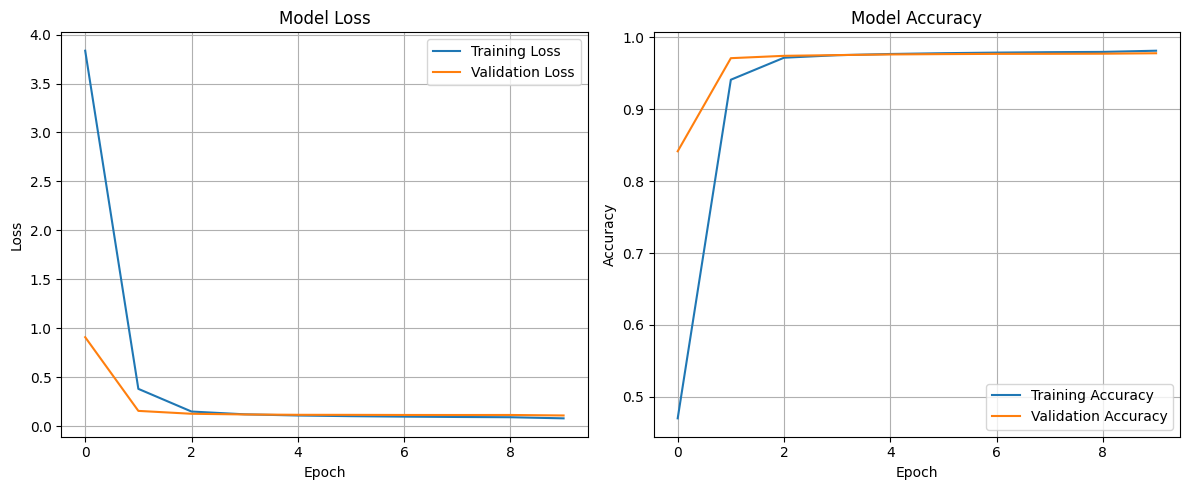

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
model.save('kalevala_model.keras')
print("Model saved as 'kalevala_model.keras'")

Model saved as 'kalevala_model.keras'


## Text Generation

Text is generated token-by-token using the trained model.



In [15]:
def generate_text(prompt, max_tokens=100, temperature=0.3):
    tokens = sp.encode_as_ids(prompt)

    for _ in range(max_tokens):
        input_seq = tokens[-seq_length:]
        input_seq = [0] * (seq_length - len(input_seq)) + input_seq
        input_seq = np.array([input_seq])

        logits = model.predict(input_seq, verbose=0)[0, -1]

        logits = logits / temperature
        probs = keras.ops.softmax(logits).numpy()

        next_token = np.random.choice(len(probs), p=probs)
        tokens.append(next_token)

    return sp.decode_ids(tokens)

In [21]:
model = keras.models.load_model("kalevala_best_model.keras")

### Temperature

Controls randomness in output:

#### Low (0.3):
- closely follows training data
#### Medium (0.7):
- balanced
#### High (1.0–1.5):
- more random

In [18]:
prompt = "Vaka vanha Väinämöinen"

for temp in [0.3, 0.7, 1.0, 1.5]:
    print(f"\nTemperature {temp}:")
    print(generate_text(prompt, max_tokens=100, temperature=temp))


Temperature 0.3:
Vaka vanha Väinämöinen, tietäjä iän-ikuinen, takoi miehen tarpehia; takoi tuuria tusinan, avaimia aika kimpun, kelpo kimpun keihä'itä, eikä suurta eikä pientä, takoi kerran keskoisia. Louhi, Pohjolan emäntä, Pohjan akka harvahammas, siitti siivet sulkinensa, levahutti lentämähän. Lenteli liki kotia, tuosta loihe loitommaksi, poikki Pohjolan merestä sepon Ilmarin pajalle. Aukoi seppo ikkunansa, katsoi, kuin tulisi tuuli: ei ollut tulento tuulen, oli harmoa havukka. Se on seppo Ilmarinen sanan virkkoi, noin nimesi: "Mit' olet, otus,

Temperature 0.7:
Vaka vanha Väinämöinen, tietäjä iän-ikuinen, sillä riisui rikkehiä, purkaeli puuttehia. Poies poisti poikenluomat, paranti pahat panoset, päästi kansan kuolemasta, Kalevan katoamasta. Kuudesviidettä runo Sai sanoma Pohjolahan, tieto kylmähän kylähän Väinölän vironneheksi, Kalevalan pääsneheksi noista nostamavioista, tauista tavattomista. Louhi, Pohjolan emäntä, Pohjan akka harvahammas, tuo tuosta kovin pahastui. Sanan virkk

In [ ]:
"""
# Load saved model
model = keras.models.load_model('kalevala_model.keras')

sp = spm.SentencePieceProcessor()
sp.load('kalevala_sp.model')

prompt = "Mieleni minun tekevi"
generated = generate_text(model, sp, prompt, num_tokens=150, temperature=1.0)
print(generated)
"""

'\n# Load saved model\nmodel = keras.models.load_model(\'kalevala_model.keras\')\n\n# Load SentencePiece tokenizer\nsp = spm.SentencePieceProcessor()\nsp.load(\'kalevala_sp.model\')\n\n# Test generation\nprompt = "Mieleni minun tekevi"\ngenerated = generate_text(model, sp, prompt, num_tokens=150, temperature=1.0)\nprint(generated)\n'

## Model Size Experiment

Two configurations were tested:

##### Small Model
Faster training
Lower memory usage
Learns basic structure
More repetition in generated text
##### Large Model
Slower training
Better coherence and fluency
Captures deeper structure of language
Produces more natural text

## Comparison
settings:
<br>
Smaller: embed_dim = 128, num_heads = 2, num_layers = 2, ff_dim = 256, seq_length = 32
<br>
Larger: embed_dim = 256, num_heads = 4, num_layers = 3, ff_dim = 512, seq_length = 64
<br> 
| Model | Train Acc | Val Acc | Val Loss |
| :--- | :---: | ---: | ---: |
| Small | ~95% | ~95% | ~0.23 |
| Large | ~98% | ~97.8% | ~0.10 |

### Observations
- Smaller models learn surface-level patterns
- Larger models capture deeper structure
- Increasing model size improves quality but increases training time significantly

Training Transformers from scratch was difficult because it contains a large number of parameters and it requires large datasets.

### Conclusion

This notebook demonstrates how a Transformer model can be built from scratch for text generation.

Key findings:

Transformer models can learn complex language structure even without pretraining
Model size has a major impact on text quality
Temperature strongly affects generation style and randomness
Larger models produce more coherent and natural outputs

Overall, this experiment highlights both the power and the challenges of training Transformer-based language models from scratch.